<a id="top"></a>
# Visualization of Roman APT products
***

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.1". 

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.

## Introduction

This notebook shows how to: 
1. Check if an astronomical source will be observed by one of the Roman's Community-Defined Surveys and
2. Illustrate several examples of how to visualize APT products in Python. Note that the APT GUI already has Aladin visualization, and the tool presented in this notebook is complementary.

The utility functions defined in `footprint_utils.py` use the so-called __simulator input__ file.
* A simulator input file, originally intended to work as input for Roman's image simulation software: Roman I-Sim, contains information about all exposures and the position of the `WFI_CEN` aperture, together with duration, and filter element.

In this notebook, we will demonstrate how to build visualizations of the simulator input files serially or in parallel. Note: In order to take full advantage of parallelization, the parameters (number of threads / number of processes) need to be optimized according to the machine and inputs used.

This notebook makes extensive use of [`healsparse`](https://healsparse.readthedocs.io), which is based on [`HEALPix`](https://ui.adsabs.harvard.edu/abs/2005ApJ...622..759G/abstract). We introduce some of the basic usage here, but recommend following their respective documentation sources in order to find out more about their usage.


## Imports

- *numpy* to handle array functions
- *matplotlib* for plotting data
- *astropy.table* for creating tidy tables of the data
- *pandas* for creating tidy tables of the data
- *pysiaf* to get the coordinates of WFI in different frames of reference (used internally in `footprint_utils`)
- [*healpy*](https://healpy.readthedocs.io/en/latest/) to generate all-sky maps (used internally in `footprint_utils`)
- [*hpgeom*](https://hpgeom.readthedocs.io/en/latest/#) to handle quick healpix operations (used internally in `footprint_utils`)
- [*healsparse*](https://healsparse.readthedocs.io/en/stable/index.html) to generate lightweight partial-sky high-resolution HEALPix maps
- [*skyproj*](https://skyproj.readthedocs.io/en/latest/index.html) to generate sky plots using different projections
- *astropy.coordinates* to handle sky coordinates and transformations
- *astropy.units* to handle unit conversions
- *dask* (Optional) to perform parallel processing

Two packages that will be used throughout the notebook are `healsparse` and `skyproj`. If  not installed already, you want to install these; please uncomment the cell below:

In [1]:
# healsparse>=1.11.1
# %pip install ipympl
# %pip install healpy
# %pip install healsparse

In [2]:
import numpy as np
from footprint_utils import *
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import astropy.table
import ipympl
from astropy.coordinates import SkyCoord
import astropy.units as u

In [3]:
import healpy as hp
import healsparse as hsp
import skyproj

# Dask imports
from dask.distributed import Client, progress, as_completed
import dask.array as da
import dask
from functools import partial

By default, this notebook will allow you to produce interactive plots; however, some of the plots presented here could lead to reduced performance in certain systems. In order to generate static plots, set the `interactive` variable below to `False`.

In [4]:
interactive = True
if interactive:
    %matplotlib widget
else:
    %matplotlib inline

***

# Determine if a source is within a Survey Footprint

The planned [Roman Community-Defined Surveys](https://roman-docs.stsci.edu/roman-community-defined-surveys) (CCS) will observe a large fraction of the sky; thus, many known astronomical sources will be observed by Roman during the course of its main mission.

In order to find whether or not any of the surveys cover a particular position of the sky, and the expected total exposure time at the end of the mission, the Science Operations Center has assembled maps based on the latest implementation of the Community-Defined surveys.

If you are curious about how these maps are assembled, please follow the instructions in the section [Visualizing Footprints of APT Survey Programs](#Visualizing-Footprints-of-APT-Survey-Programs) in this notebook.

In this first section, however, we will showcase how to read the pre-generated exposure time maps for the different Community-Defined surveys and how to query a set of positions. Finally, we will showcase how to visualize the results.

## Opening a healsparse map

`healsparse` is a sparse implementation of `HEALPix` that allows the user to open high-resolution sky maps, without having to carry full-sky information in memory. This package was originally designed for Rubin's Legacy Survey of Space and Time, although it is especially performant for maps where the fraction of the sky observed is small or sparse (hence the name).

The basic idea behind the package is that a `HealSparseMap` object contains two layers: a low-resolution `coverage_map` that indicates the patches where data has been observed, and a high-resolution sparse map that contains the quantity (or quantities) of interest.

The Roman's SOC has pre-generated a set of maps based on all the Community-defined surveys. We will show how to read these below.

We use a convenience function called `get_survey_maps_uri` to retrieve the maps filenames for a given Community-Defined Survey and a given filter element. In this example, we will be using the map corresponding to all of the exposures in the F158 filter for the High-Latitude Wide-Area Survey (HLWAS) by the end of Roman's primary mission. The `aux_maps` directory contains maps for each of the Community-Defined Surveys: High-Latitude Time Domain Survey (HLTDS), Galactic Bulge Time Domain Survey (GBTDS), Galactic Plane Survey (GPS), and the aforementioned HLWAS. For the HLWAS, and the HLTDS we include an optional parameter to subselect a tier. For the HLWAS the allowed options are (`'MEDIUM', 'WIDE', 'DEEP', 'ULTRA-DEEP', or 'ALL'`), whereas for the HLTDS we allow `('DEEP', 'WIDE', 'ALL')`

**Note**: The roll angle for some of the pre-generated maps presented in this notebook might not be representative of the on-orbit exposures.

In [5]:
help(get_survey_maps_uri)
map_uri = get_survey_maps_uri('HLWAS', 'F158', tier='ALL')  # You can choose your favorite survey and filter element
# In this case we will use the map ./aux_data/map_HLWAS-all_F158.hsp
print(map_uri)

my_map = hsp.HealSparseMap.read(map_uri)  # You can change the path and point to any of the provided maps in the aux_data subdirectory

Help on function get_survey_maps_uri in module footprint_utils:

get_survey_maps_uri(survey_name, band, tier=None)
    Utility function to retrieve the relevant pre-generated
    survey exposure-time maps

    Params:
    -------
    survey_name (str) : Survey name -- allowed options are [HLTDS, HLWAS, GBTDS, GPS]
    band (str) : Filter element of interest
                 -- allowed options are [F062, F087, F106, F129, F146, F158, F814, F213, PRISM, GRISM]
    tier (str) : Survey tier -- only available for HLWAS and HLTDS

    Returns:
    --------
    file_name (str) : Path to pre-generated healsparse map containing the exposure time for the
    selected survey / filter combination

./aux_data/map_HLWAS-all_F158.hsp


Once we read the map, we have access to a complete low-resolution coverage map that spans the whole sky. This is used to check if the data exists in this broad sky region and to jump to the right spot in the space high-resolution data or sparse map.  In this case, the resolution of the coverage map is set to `inside_coverage`.

In [6]:
my_map.nside_coverage, my_map.coverage_map 

(32,
 array([0.        , 0.        , 0.01690674, ..., 0.        , 0.        ,
        0.        ], shape=(12288,)))

You can use standard `healpy` routines to visualize this map.

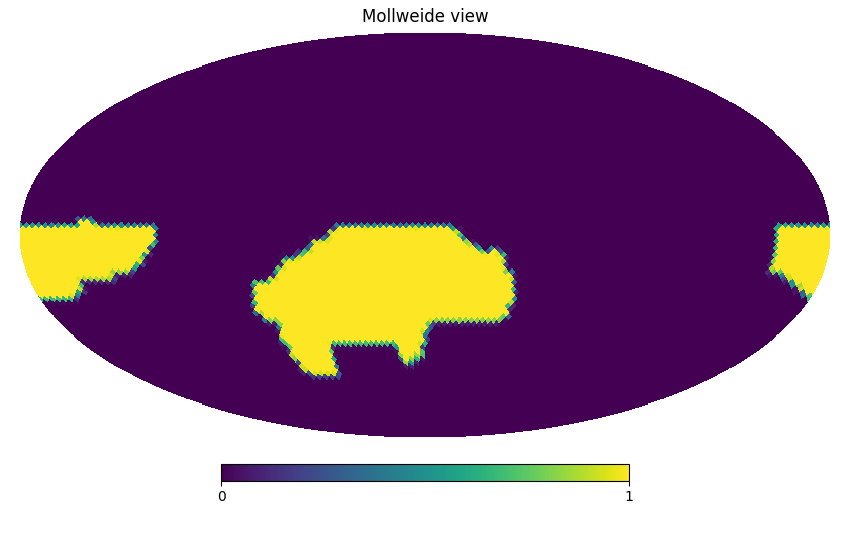

In [7]:
hp.mollview(my_map.coverage_map, nest=True)
plt.show()

The map that we are most interested in is the sparse map. This map contains the total expected exposure time in seconds for the chosen filter and survey by the end of Roman's primary mission. The recommended way to access its values is to use the `get_values_pos()` or the `get_values_pix()` methods. For more information about handling and visualizing `healsparse` maps, please follow the documentation [here](https://github.com/LSSTDESC/healsparse/blob/main/tutorial/quickstart.ipynb) and [here](https://github.com/LSSTDESC/skyproj/blob/main/tutorial/tutorial_healsparse.ipynb).

The resolution of a `healsparse` sparse map is controlled by the `nside_sparse` parameter. This parameter is the equivalent of `HEALPix`'s `nside`, and controls the number of pixels into which the full celestial sphere is divided. The total number of pixels is given by `12*nside**2`, and the resolution of the map can be computed by using `hp.nside2resol()`. 

Something to note about a sparse map is that it will show a placeholder value or sentinel value for the pixels that are not observed in the map. In the case of our maps, the sentinel value corresponds to `HEALPix`'s unseen value `hp.UNSEEN=-1.6375e+30`. 

In [8]:
print('nside_sparse: ', my_map.nside_sparse)
print('Map resolution: ', hp.nside2resol(my_map.nside_sparse, arcmin=True), 'arcmin')

nside_sparse:  4096
Map resolution:  0.8588716029543515 arcmin


In [9]:
# Check the value of the map in an arbitrary position

probe_exp_time = my_map.get_values_pos(60, -10)
if probe_exp_time < 0:
    print('Position not observed')
else:
    print('Expected exposure time [s]', probe_exp_time) 

Expected exposure time [s] 645.1439399999999


## Querying and plotting survey maps

So, to solve the core question of: "Is this astronomical source observed in this survey?", we can repeat this process at a larger scale.

In [10]:
# We are going to generate 1000 points randomly in the celestial sphere. We will do this randomly, but you can
# substitute this by your own sources (read them from a file or otherwise write the coordinates here)
npoints = 1000
test_ra = 360*np.random.random(size=npoints)
test_dec = np.degrees(np.arcsin(-1+2*np.random.random(size=npoints)))

coordinates = SkyCoord(ra=test_ra*u.deg, dec=test_dec*u.deg)

exp_times_at_positions = my_map.get_values_pos(coordinates.ra.deg, coordinates.dec.deg)

observed = exp_times_at_positions > 0

`exp_times_at_positions` will contain the exposure time in seconds at the positions that we are probing, and `observed` will be a boolean array with the same length as our probe positions.

We will finish this section by showing how to visualize these results quickly. In this example, the observed sources will be shown as blue dots, and the not observed sources will be shown as light orange dots.

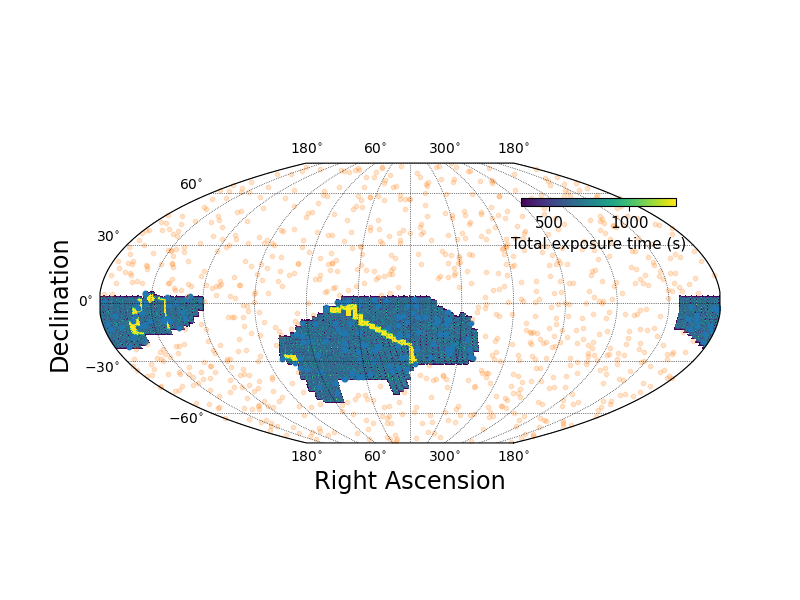

In [11]:
fig = plt.figure(4, figsize=(8, 6))
fig.clf()
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax)


# Plotting HealSparse map. 
# Note that the default is to zoom in to the range defined by the map
plot_label = 'Total exposure time (s)'
_ = sp.draw_hspmap(my_map, label='Exposure time map')
cbar, _ = sp.draw_inset_colorbar(label=plot_label, height='3%', bbox_to_anchor=(-0.06, -0.1, 1, 1), loc=1) 
sp.set_extent([-180, 180, -90, 90])
sp.ax.scatter(coordinates.ra.deg[observed], coordinates.dec.deg[observed], c='C0', s=10, label='Observed points')  
sp.ax.scatter(coordinates.ra.deg[~observed], coordinates.dec.deg[~observed], c='C1', s=10, alpha=0.2, label='Not observed points')
plt.show()

You can also convert a `HealSparseMap` object into a regular `HEALPix` map if needed. Note that for high values of the `healsparse` input parameter `nside_sparse` (> 8192) it will take up a significant amount of memory to do so. The `generate_healpix_map` method will generate a HEALPix map with the desired output `nside`. If this parameter is different than the native `nside_sparse`, some reduction operation will be performed (by default, it will take the mean). By default, it uses NEST ordering, which is one implementation of [HEALPix labeling](https://healpix.sourceforge.io/html/intro_Geometric_Algebraic_Propert.htm#SECTION410).

In [12]:
hpix_map = my_map.generate_healpix_map(nside=4096) 

And `hpix_map` is a regular `HEALPix` map, so it can be used with the typical `healpy`'s routines.

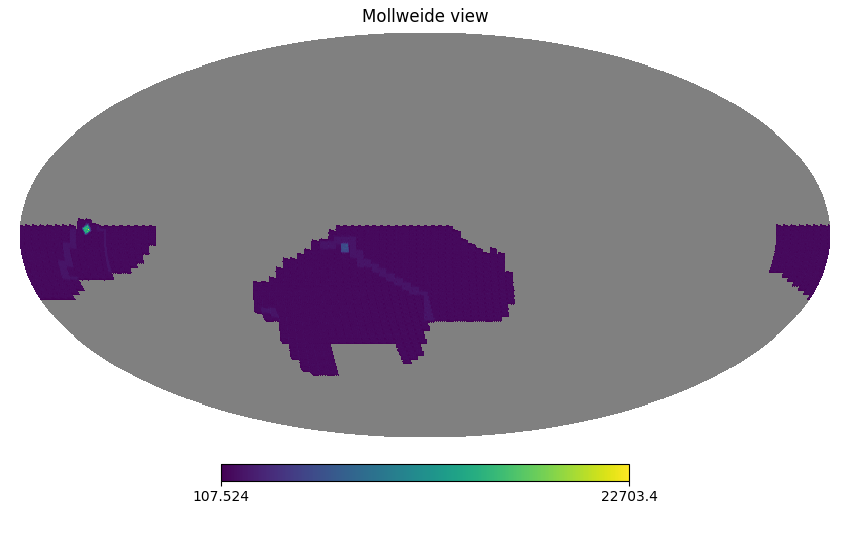

In [13]:
hp.mollview(hpix_map, nest=True)
plt.show()

***

# Visualizing Footprints of APT Survey Programs

The [Astronomer's Proposal Tool (APT)](https://roman-docs.stsci.edu/raug) allows users to design a General Astrophysics Survey with the Wide Field Instrument, and it was used to design the Roman Core Community Surveys. Given an APT program, the user can export a variety of products using the command line. In this notebook, we will focus on a specific product: the `simulator input` file.

The `aux_data` directory includes such files for the most up-to-date versions of the CCS: `roman_<survey>.sim.ecsv`.

For demonstration purposes, we use a subset of a program for the [High-Latitude Wide-Area Survey](https://science.nasa.gov/mission/roman-space-telescope/high-latitude-wide-area-survey/}).

Starting with APT version 2026.2, users will be able to export these files for any APT program by executing the following one-line command in a terminal:

    /PATH_APT_EXECUTABLE/bin/apt -export -nogui sim /PATH_APT_FILE/my_apt_file.apt -nogui -output /PATH_TO_OUTPUT_DIRECTORY

This command will generate a simulator input file: `my_apt_file.sim.ecsv` in the output directory given in the `-output` argument. 

In the next sections, we will describe what these files contain and how to read them.

## Reading a simulator input file `sim.ecsv`

The simulator input file `*.sim.ecsv` is an APT output intended for use as input to Roman I-Sim to generate simulated images. It contains information about the position `RA, Dec` of the `WFI_CEN` aperture for each exposure in the program, together with information about the filter element used, and the duration in seconds (Note: duration is not exposure time, but exposure time + potential slew times / estimated overheads). These files are in `ecsv` format, so they can easily be read by `pandas` or `astropy` (recommended for automatic parsing). In this example, we use `astropy`.

In [14]:
# Generate the astropy table object and
# inspect the results
sim_table = astropy.table.Table.read('./aux_data/roman_hlwas.sim.ecsv')
sim_table

RA,DEC,PA,BANDPASS,MA_TABLE_NUMBER,DURATION,PLAN,PASS,SEGMENT,OBSERVATION,VISIT,EXPOSURE,EXPOSURE_TIME,TARGET_NAME
float64,float64,float64,str5,int64,int64,int64,int64,int64,int64,int64,int64,float64,str19
151.964359,2.164771,290.0,F087,1018,324,1,1,1,1,1,1,294.10974,COSMOS
152.073363,2.216955,290.0,F087,1018,324,1,1,1,1,1,2,294.10974,COSMOS
152.245927,2.299564,290.0,F087,1018,372,1,1,1,1,1,3,294.10974,COSMOS
151.653969,1.904786,290.0,F087,1018,324,1,1,1,1,2,1,294.10974,COSMOS
151.762989,1.956986,290.0,F087,1018,324,1,1,1,1,2,2,294.10974,COSMOS
151.935585,2.039622,290.0,F087,1018,372,1,1,1,1,2,3,294.10974,COSMOS
151.343568,1.644755,290.0,F087,1018,324,1,1,1,1,3,1,294.10974,COSMOS
151.452592,1.696968,290.0,F087,1018,324,1,1,1,1,3,2,294.10974,COSMOS
151.625203,1.779626,290.0,F087,1018,372,1,1,1,1,3,3,294.10974,COSMOS


The `astropy.table.Table` object contains the `RA, DEC, PA` of the `WFI_CEN` aperture. The filter element is displayed in the `BANDAPASS` column. The[`MA_TABLE_NUMBER`](https://roman-docs.stsci.edu/roman-instruments-home/wfi-imaging-mode-user-guide/observing-with-the-wfi-in-imaging-mode/wfi-multiaccum-tables) column indicates the identification number of the MultiAccum table. The `DURATION` column indicates timing information. `PLAN` is the [Execution Plan's](https://roman-docs.stsci.edu/raug/astronomers-proposal-tool-apt/execution-plans) number. `PASS` corresponds to the [`Pass`](https://roman-docs.stsci.edu/raug/astronomers-proposal-tool-apt/pass-plans) number in the survey activities in APT. `SEGMENT` corresponds to the segment number within a pass. `OBSERVATION` corresponds to the observation number in a pass (i.e., the pass number in a pass, and it matches `Observation` in the `obs_all` DataFrame). `VISIT` corresponds to the `Mosaic Tile` number in the mosaic segment (in the `obs_all` DataFrame). `EXPOSURE` is the exposure (dither) number for a tile. `EXPOSURE_TIME` indicates the exposure time in seconds. Finally, `TARGET_NAME` indicates the name of the target in the APT program.

Using this table, we will visualize all the exposures in the `F158` filter and check the total exposure time.

In [15]:
table_mask = sim_table['BANDPASS'] == 'F158'
sub_table = sim_table[table_mask]
exp_time = sub_table['EXPOSURE_TIME'].data
ra_sim = sub_table['RA'].data
dec_sim = sub_table['DEC'].data
pa_sim = sub_table['PA'].data
print('Number of selected exposures', len(sub_table))

Number of selected exposures 108348


In this case, instead of a reference position and the relative `V2`, `V3` angles, we directly have the `RA`, `DEC`, and `PA` of the `WFI_CEN` aperture, so that we can use these directly via `build_single_exp_map_cen`. Let's start with a single segment within the HLWAS medium field (Pass 97).

In [16]:
# Setting resollution parameters used by HEALPix
nside_cov = 32  # nside_cov controls the resolution of the low-resolution coverage map (smaller = larger area coverage)
nside_sparse = 4096  # nside_sparse controls the resolution of the high-resolution map (bigger = more resolution)

Focusing on Pass 97 and Segment 1, we calculate the healpixels that cover a single exposure at all pointing positions using a convenience function defined in `footprint_utils.py`. 

In [17]:
# Filter Pass Plan and Segment
mask_here = (sub_table['PASS'] == 97) & (sub_table['SEGMENT'] == 1)
print('Going to use', np.count_nonzero(mask_here), 'exposures')

# Create footprint for all exposures
map_result = None
for ra, dec, pa, et in zip(ra_sim[mask_here], dec_sim[mask_here], pa_sim[mask_here], exp_time[mask_here]):
    map_here = build_single_exp_map_cen(ra, dec, pa, et, nside_cov=nside_cov, nside_sparse=nside_sparse)
    if map_result is None:
        map_result = map_here
    else:
        # map_results will have coverage from all maps
        map_result = hsp.sum_union([map_result, map_here])

Going to use 48 exposures


Now we can inspect the resulting footprint of all exposures for this Pass and Segment using the interactive map.

/tmp/ipykernel_3756/769554190.py:2: UserWarning: Ignoring specified arguments in this call because figure with num: 4 already exists
  fig = plt.figure(4, figsize=(8, 6))


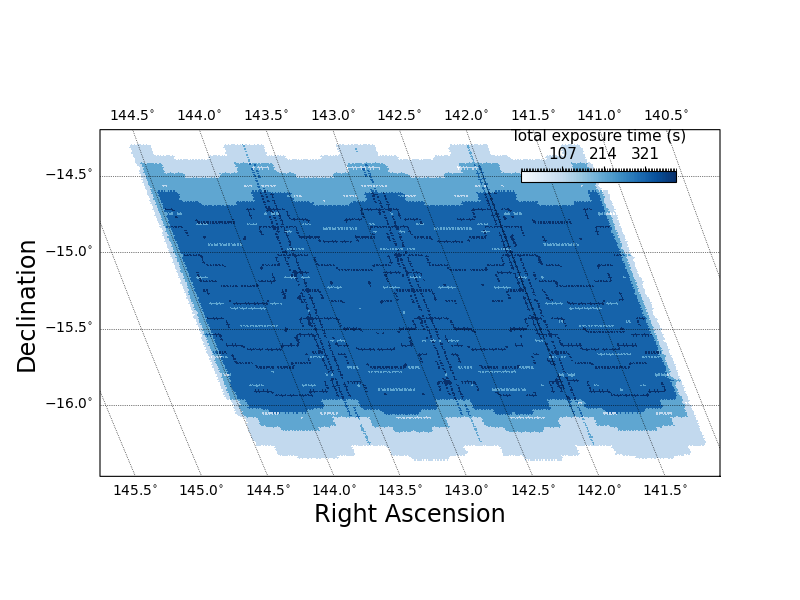

In [18]:
# Define plot parameters
fig = plt.figure(4, figsize=(8, 6))
fig.clf()
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax)

# We define a custom colorbar for illustration purposes
# and create the new map. 
cmap = plt.cm.Blues  # define the colormap
cmaplist = [cmap(i) for i in range(cmap.N)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)
bounds = np.linspace(0, 400, 100)
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# Plotting HealSparse map. 
# Note that the default is to zoom in to the range defined by the map
plot_label = 'Total exposure time (s)'
_ = sp.draw_hspmap(map_result, cmap=cmap, norm=norm)
cbar, _ = sp.draw_inset_colorbar(label=plot_label, height='3%', bbox_to_anchor=(-0.06, -0.1, 1, 1), loc=1, ticks=[107, 214, 321])  # Set up the colorbar
cbar.ax.set_xticklabels(['107', '214', '321'])
plt.show()

## Dealing with large programs. Creating maps with `dask`.

With large programs, executing these loops serially becomes cumbersome. Given that each segment is independent, we can parallelize the processes.

To optimize memory usage, we split the work into niter batches and compute each batch in parallel using Dask. Once computed, we sum the results of each batch and accumulate them into a final total map.

**Note**: if you have memory issues, consider increasing the number of batches to `niter=10` or more.

In [19]:
# Number of batches
niter = 3

In [20]:
# Starts a Dask distributed scheduler (if one isn’t already running).
client = Client(processes=True)  # In some instances processes=False will perform better

Set the plot parameters. For this notebook, we cap the number of exposures to 6,000 so the demo runs quickly. Please feel free to remove `nmax` below or set it to -1 to run for all `F158` exposures.

In [21]:
# Setting the plot parametes
table_mask = sim_table['BANDPASS'] == 'F158'
sub_table = sim_table[table_mask]


# Setting up a max number of exposures
# Change to -1 in order to run for the full dataset
nmax = 6000
exp_time = sub_table['EXPOSURE_TIME'].data[:nmax]
ra_sim = sub_table['RA'].data[:nmax]
dec_sim = sub_table['DEC'].data[:nmax]
pa_sim = sub_table['PA'].data[:nmax]

For each iteration, `client.map()` takes a subset of the pointings and builds individual exposure maps in parallel. We then combine all those individual maps into one combined map.

In [22]:
map_all = []
for i in range(niter):
    print('Iteration', i)
    imin = (i*len(ra_sim))//niter
    imax = ((i+1)*len(ra_sim))//niter
    ra_subset = ra_sim[imin:imax]
    dec_subset = dec_sim[imin:imax]
    pa_subset = pa_sim[imin:imax]
    exp_subset = exp_time[imin:imax]

    # Build individual maps in parallel
    map_here = client.map(partial(build_single_exp_map_cen, 
                          nside_sparse=nside_sparse, nside_cov=nside_cov),
                          ra_subset, dec_subset, pa_subset, exp_subset
                          )
    
    map_partial = client.map(hsp.sum_union, [map_here])
    res_here = map_partial[0].result()
    map_all.append(res_here)

Iteration 0


Iteration 1


Iteration 2


In [23]:
# Close the dask client
client.close()

2026-05-29 15:32:55,665 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File 

In [24]:
# Sum the nint batch maps into the final total exposure/coverage map
map_f158 = hsp.sum_union(map_all)

Now we can inspect the new map for all the exposures

/tmp/ipykernel_3756/1500955711.py:1: UserWarning: Ignoring specified arguments in this call because figure with num: 5 already exists
  fig = plt.figure(5, figsize=(12, 6))


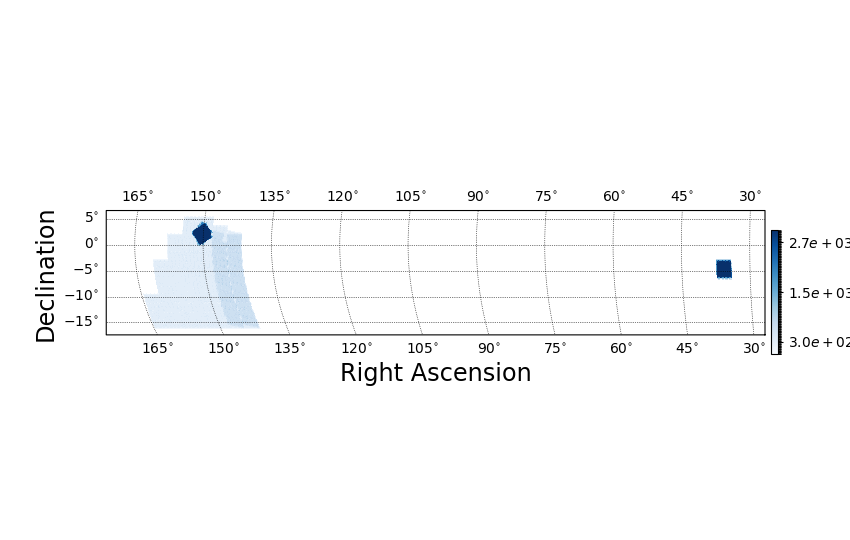

In [25]:
fig = plt.figure(5, figsize=(12, 6))
fig.clf()
ax = fig.add_subplot(111)
sp = skyproj.McBrydeSkyproj(ax=ax)

cmap = plt.cm.Blues  # define the colormap
cmaplist = [cmap(i) for i in range(cmap.N)]

# create the new map
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)
bounds = np.linspace(0, 3000, 200)
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
# Note that the default is to zoom in to the range defined by the map
_ = sp.draw_hspmap(map_f158, cmap=cmap, norm=norm)
# Set up the colorbar
cbar, _ = sp.draw_inset_colorbar(label='Total exposure time (s)', height='100%', width='1%', orientation='vertical',
                                 bbox_to_anchor=(+0.03, -0.1, 1, 1), loc=1)
plt.show()

Note that the resulting `healsparse` maps can be saved to disk using the `write` method provided in the cell bellow.

Disclaimer: Depending on the map resolution (controlled by the `nside` parameter) it can generate a very large file.

In [26]:
# map_f158.write('./aux_data/map_f158_all.hsp', clobber=True)  # Uncomment if you want to write the map to disk. With the default parameters in this notebook it should use 45 MB.

***

## About this Notebook

**Author(s):** Javier Sánchez and Rosa Diaz <br>
**Keyword(s):** Tutorial, visualization, survey footprints <br>
**Last Updated:** March 2026 <br>
**Next Review:** 

<table width="100%" style="border:none; border-collapse:collapse;">


  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>